# Formula SAE G-G diagram

Compute the acceleration envelope of the electric FSAE model with the Hoosier MF6.2 + MNC tire.

In [1]:
import os
import sys
import tempfile
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repository_root(start=Path.cwd()):
    for directory in (start, *start.parents):
        if (directory / "database" / "vehicles" / "fsae").is_dir():
            return directory
    raise FileNotFoundError("Start Jupyter inside the fastest-lap repository.")


REPO_ROOT = find_repository_root()
default_python_dir = (
    REPO_ROOT / "build" / "artifacts" /
    "fastestlap-python-windows-mingw64-x86_64-fsae-gg" / "python"
)
python_dir = Path(os.environ.get("FASTESTLAP_PYTHON_DIR", default_python_dir))
if python_dir.is_dir():
    sys.path.insert(0, str(python_dir))

import fastest_lap
from fastest_lap import KMH

print(f"fastest_lap: {Path(fastest_lap.__file__).resolve()}")

fastest_lap: D:\projects\fastest-lap\build\artifacts\fastestlap-python-windows-mingw64-x86_64-fsae-gg\python\fastest_lap.py


## Load the electric FSAE vehicle

A temporary XML copy receives the absolute fitted-tire path; the database XML is not modified.

In [2]:
fsae_database = REPO_ROOT / "database" / "vehicles" / "fsae"
source_xml = fsae_database / "fsae-2026-electric-frucd.xml"
tire_filename = "Hoosier_R20_16(18)x75(60)-10x8(7).mat"
tire_file = Path(os.environ.get(
    "FASTESTLAP_FSAE_TIRE_FILE", fsae_database / tire_filename
)).resolve()
if not tire_file.is_file():
    raise FileNotFoundError(
        f"Tire data not found at {tire_file}; set FASTESTLAP_FSAE_TIRE_FILE."
    )

temporary_directory = tempfile.TemporaryDirectory(prefix="fastestlap-fsae-gg-")
runnable_xml = Path(temporary_directory.name) / source_xml.name
tree = ET.parse(source_xml)
for node in tree.getroot().findall(".//mat-file"):
    node.text = str(tire_file)
tree.write(runnable_xml, encoding="utf-8", xml_declaration=True)

vehicle = "fsae-electric-gg-example"
fastest_lap.create_vehicle_from_xml(vehicle, str(runnable_xml))
print(f"vehicle type: {fastest_lap.variable_type(vehicle)}")

vehicle type: fsae-electric-3dof


## Compute the envelope

Use a representative autocross speed. Fifty points provide a smooth continuation while keeping the notebook runtime practical.

In [3]:
speed_kmh = 60.0
n_points = 50
ay, ay_minus, ax_max, ax_min = fastest_lap.gg_diagram(
    vehicle, speed_kmh * KMH, n_points
)

for values in (ay, ay_minus, ax_max, ax_min):
    assert np.isfinite(values).all()

print(
    f"{speed_kmh:.0f} km/h: lateral peak = {max(ay):.3f} g, "
    f"ax range = [{min(ax_min):.3f}, {max(ax_max):.3f}] g"
)

60 km/h: lateral peak = 1.371 g, ax range = [-0.487, 0.661] g


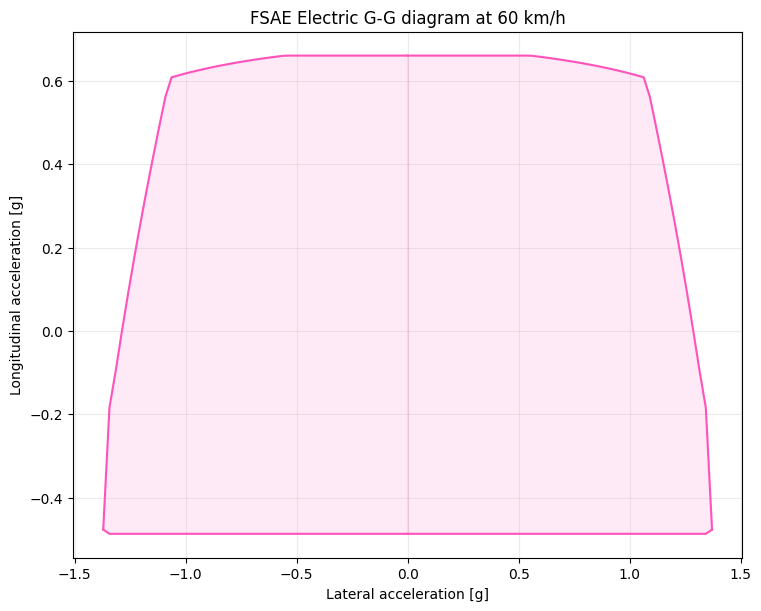

In [4]:
fig, axis = plt.subplots(figsize=(7.5, 6.0), constrained_layout=True)
for lateral in (ay, ay_minus):
    axis.plot(lateral, ax_max, color="#FE53BB")
    axis.plot(lateral, ax_min, color="#FE53BB")
axis.fill_between(ay, ax_min, ax_max, color="#FE53BB", alpha=0.12)
axis.fill_between(ay_minus, ax_min, ax_max, color="#FE53BB", alpha=0.12)
axis.set(
    xlabel="Lateral acceleration [g]",
    ylabel="Longitudinal acceleration [g]",
    title=f"FSAE Electric G-G diagram at {speed_kmh:.0f} km/h",
)
axis.grid(True, alpha=0.25)
plt.show()

In [5]:
fastest_lap.delete_variable(vehicle)
temporary_directory.cleanup()